In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

# 1.1 Load the CSV [cite: 261]
df = pd.read_csv('data_tp_churn.csv')

# 1.2 Inspect data [cite: 262]
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values Count:\n", df.isnull().sum())

# 1.3 Sort by Period and verify time range [cite: 263]
df = df.sort_values('Periode').reset_index(drop=True)
print(f"\nTime Range: Period {df['Periode'].min()} to {df['Periode'].max()}")

Dataset Shape: (5000, 6)

First 5 rows:
    Periode  Anciennete  Montant_Mensuel  Support_Appels  Contrat  Churn
0        3           6            92.87             1.0  Mensuel      1
1       19          36            98.26             2.0     1 an      0
2       16          41            42.90             0.0    2 ans      0
3       11          53            24.69             2.0    2 ans      0
4       11          41            52.57             1.0  Mensuel      0

Data Types:
 Periode              int64
Anciennete           int64
Montant_Mensuel    float64
Support_Appels     float64
Contrat             object
Churn                int64
dtype: object

Missing Values Count:
 Periode              0
Anciennete           0
Montant_Mensuel    670
Support_Appels     493
Contrat              0
Churn                0
dtype: int64

Time Range: Period 1 to 24


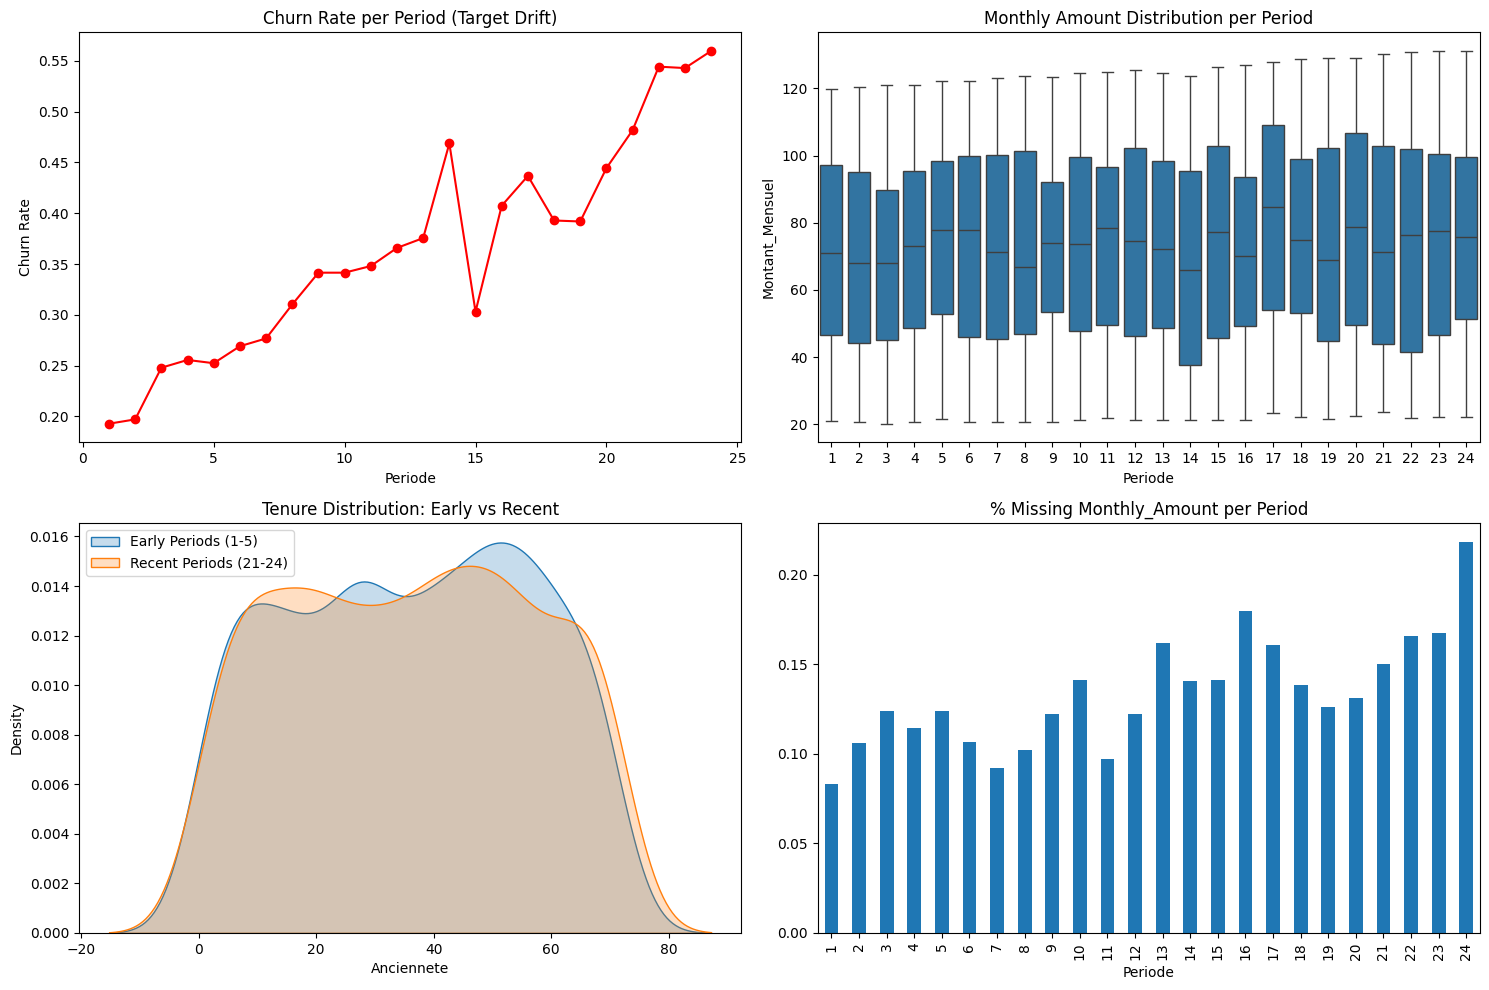

MNAR Discussion: Missingness in Support_Calls or Monthly_Amount may be correlated with Churn.


In [16]:
plt.figure(figsize=(15, 10))

# Figure 1: Churn rate per period [cite: 271]
plt.subplot(2, 2, 1)
df.groupby('Periode')['Churn'].mean().plot(kind='line', marker='o', color='red')
plt.title('Churn Rate per Period (Target Drift)')
plt.ylabel('Churn Rate')

# Figure 2: Covariate drift (e.g., Monthly Amount) [cite: 272]
plt.subplot(2, 2, 2)
sns.boxplot(x='Periode', y='Montant_Mensuel', data=df)
plt.title('Monthly Amount Distribution per Period')

# Figure 3: Distribution comparison (Early vs Recent) [cite: 273]
plt.subplot(2, 2, 3)
early = df[df['Periode'] <= 5]['Anciennete']
recent = df[df['Periode'] > 20]['Anciennete']
sns.kdeplot(early, label='Early Periods (1-5)', fill=True)
sns.kdeplot(recent, label='Recent Periods (21-24)', fill=True)
plt.title('Tenure Distribution: Early vs Recent')
plt.legend()

# Figure 4: Missing values per period [cite: 274]
plt.subplot(2, 2, 4)
df.isnull().groupby(df['Periode']).mean()['Montant_Mensuel'].plot(kind='bar')
plt.title('% Missing Monthly_Amount per Period')

plt.tight_layout()
plt.show()

# MNAR Discussion [cite: 275]
print("MNAR Discussion: Missingness in Support_Calls or Monthly_Amount may be correlated with Churn.")

In [23]:
# 3.1 Define X and y [cite: 281]
X = df.drop(columns=['Churn'])
y = df['Churn']

# 3.2 ColumnTransformer [cite: 282]
numeric_features = ['Anciennete', 'Montant_Mensuel', 'Support_Appels']
categorical_features = ['Contrat']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Median imputation [cite: 283]
    ('scaler', StandardScaler()) # Scaling [cite: 283]
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')), # Missing imputation [cite: 284]
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-hot encoding [cite: 284]
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [24]:
# Temporal Split: Train on periods 1-18, Test on 19-24 [cite: 243]
train_idx = df['Periode'] <= 18
test_idx = df['Periode'] > 18

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Logistic Regression Model [cite: 285]
lr_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression())])

lr_model.fit(X_train, y_train)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print(f"Baseline AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Baseline AUC: 0.8487


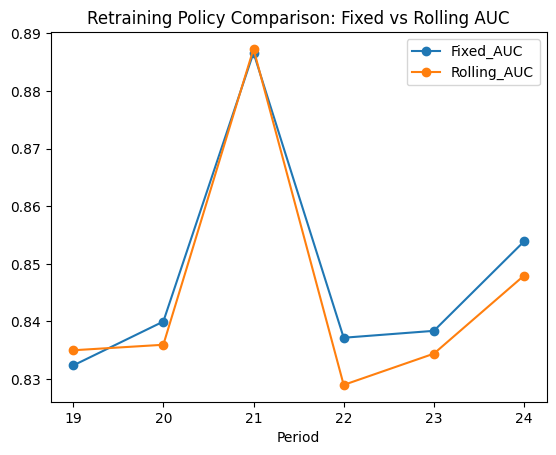

In [27]:
results = []
# Rolling window of 6 months [cite: 288]
for p in range(19, 25):
    # Fixed: Trained once on 1-18
    # Rolling: Train on past 6 months only
    train_rolling = df[(df['Periode'] >= p-6) & (df['Periode'] < p)]
    test_period = df[df['Periode'] == p]

    # Train Rolling Model
    rolling_model = Pipeline(steps=[('preprocessor', preprocessor),
                                      ('classifier', LogisticRegression())])
    rolling_model.fit(train_rolling.drop('Churn', axis=1), train_rolling['Churn'])

    # Predict
    proba_fixed = lr_model.predict_proba(test_period.drop('Churn', axis=1))[:, 1]
    proba_rolling = rolling_model.predict_proba(test_period.drop('Churn', axis=1))[:, 1]

    results.append({
        'Period': p,
        'Fixed_AUC': roc_auc_score(test_period['Churn'], proba_fixed),
        'Rolling_AUC': roc_auc_score(test_period['Churn'], proba_rolling)
    })

res_df = pd.DataFrame(results)
res_df.plot(x='Period', y=['Fixed_AUC', 'Rolling_AUC'], marker='o')
plt.title('Retraining Policy Comparison: Fixed vs Rolling AUC')
plt.show()

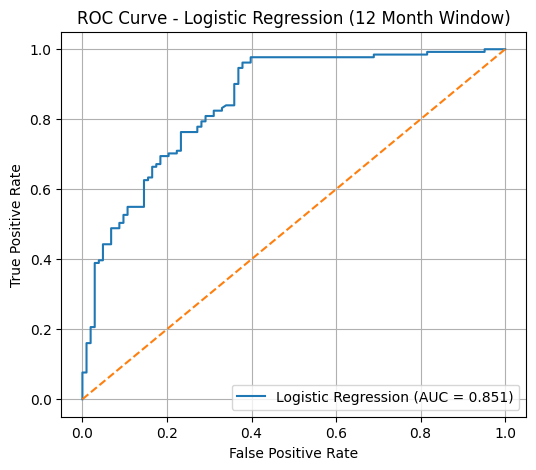

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Ensure plots render in Colab
%matplotlib inline

# ---- Train model using window = 12 ----
w = 12
# Adjust train_data to cover periods (24-12) to 23
train_data = df[(df['Periode'] >= 24-w) & (df['Periode'] < 24)]
# Adjust test_data to use the last available period, 24
test_data = df[df['Periode'] == 24]

model_12 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model_12.fit(train_data.drop('Churn', axis=1), train_data['Churn'])

y_test_12 = test_data['Churn']
y_proba_12 = model_12.predict_proba(test_data.drop('Churn', axis=1))[:, 1]

# Compute ROC
fpr_12, tpr_12, _ = roc_curve(y_test_12, y_proba_12)
roc_auc_12 = auc(fpr_12, tpr_12)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr_12, tpr_12, label=f'Logistic Regression (AUC = {roc_auc_12:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (12 Month Window)")
plt.legend()
plt.grid()
plt.show()

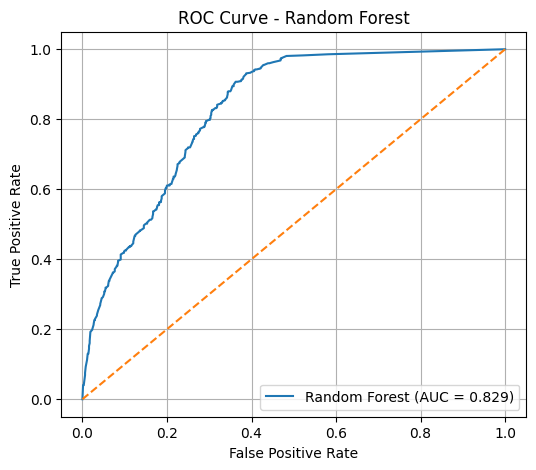

In [44]:
# Compute ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

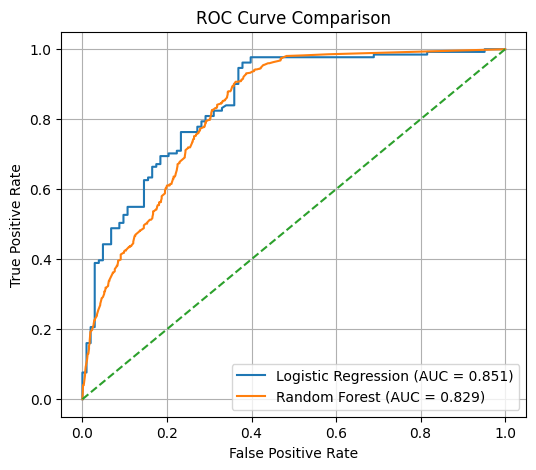

In [45]:
plt.figure(figsize=(6,5))

plt.plot(fpr_12, tpr_12, label=f'Logistic Regression (AUC = {roc_auc_12:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [35]:
rf_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Logistic Regression AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Random Forest AUC: 0.8289
Logistic Regression AUC: 0.8487


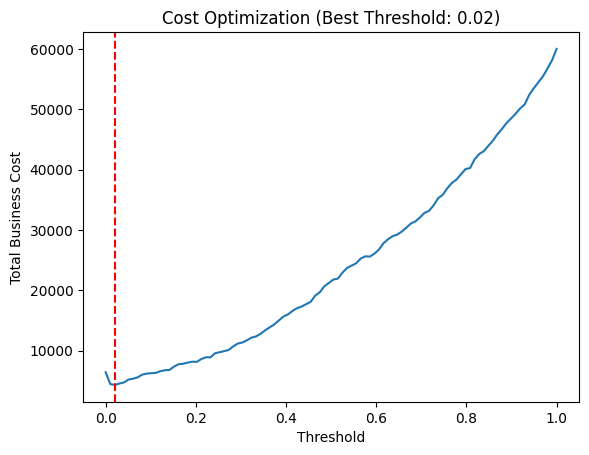

In [34]:
# Define Costs [cite: 231]
cost_FP = 10   # Cost of false retention action
cost_FN = 100  # Cost of losing a customer (lost revenue)

thresholds = np.linspace(0, 1, 100)
total_costs = []

for t in thresholds:
    y_pred = (rf_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_costs.append(fp * cost_FP + fn * cost_FN)

best_t = thresholds[np.argmin(total_costs)]
plt.plot(thresholds, total_costs)
plt.axvline(best_t, color='red', linestyle='--')
plt.title(f'Cost Optimization (Best Threshold: {best_t:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost')
plt.show()